In [1]:
import torch
import matplotlib.pyplot as plt
import pickle
import gzip
import seaborn as sns
from adjustText import adjust_text


if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

torch.no_grad().__enter__()

In [ ]:
from transformers import AutoConfig, AutoModel, AutoTokenizer

model_id = "castorini/monobert-large-msmarco"
config = AutoConfig.from_pretrained(model_id)
model = AutoModel.from_pretrained(model_id).to(device)
tokenizer = AutoTokenizer.from_pretrained(model_id)
model.to(device)
model.eval()

NUM_HEADS = config.num_attention_heads
NUM_LAYERS = config.num_hidden_layers
HIDDEN_DIM = config.intermediate_size
D_H = model.config.hidden_size  // model.config.num_attention_heads

print(f"NUM_HEADS: {NUM_HEADS}, NUM_LAYERS: {NUM_LAYERS}, HIDDEN_DIM: {HIDDEN_DIM}, HEAD_DIM: {D_H}")

/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm
/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/transformers/utils/hub.py:124: FutureWarning: Using `TRANSFORMERS_CACHE` is deprecated and will be removed in v5 of Transformers. Use `HF_HOME` instead.
  warnings.warn(
/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


NUM_HEADS: 12, NUM_LAYERS: 12, HIDDEN_DIM: 1536, HEAD_DIM: 32


/home/vast/CE-relevance-integration/.venv/lib/python3.10/site-packages/huggingface_hub/file_download.py:949: FutureWarning: `resume_download` is deprecated and will be removed in version 1.0.0. Downloads always resume when possible. If you want to force a new download, use `force_download=True`.
  warnings.warn(


In [3]:
from notebooks.utils import LayerHook, process_attention

hooks = []
for ix, layer in enumerate(model.encoder.layer):
    hook = LayerHook(ix)
    handle = layer.register_forward_pre_hook(hook)
    hook.handle = handle
    hooks.append(hook)

# MSMARCO

In [ ]:
attention_file = "/home/vast/target_dir/relevance-integrations/jobs/src.evd.attention_patterns.summarizeattentionpatterns/69a61c0b8f02d197832d15e27087bcc569c0aac10c1a59cc6940c6ddc91575f6/dataframes/" # MSMARCO


In [13]:
with gzip.open(attention_file + "/attention.pkl.gz", "rb") as fp:
    try:
        data = pickle.load(fp)    
    except ModuleNotFoundError as e:
        print(f"Missing module: {e.name}")

data.head()
rel_map = {"weak_negative": -1, "non_relevant": 0, "relevant": 1}
data["rel"] = data["rel"].map(rel_map)

In [14]:
with gzip.open(attention_file + "/attention_duplicate_token.pkl.gz", "rb") as fp:
    data_duplicate = pickle.load(fp)    

data_duplicate.rename(columns={"q2d": "dup_q2d", "d2q": "dup_d2q"}, inplace=True)
data_duplicate["rel"] = data_duplicate["rel"].map(rel_map)


In [15]:
with gzip.open(attention_file + "/attention_entropy.pkl.gz", "rb") as fp:
    data_entropy = pickle.load(fp)    

data_entropy.rename(columns={"q2d": "ent_q2d", "d2q": "ent_d2q"}, inplace=True)
data_entropy["rel"] = data_entropy["rel"].map(rel_map)

In [16]:
data_by_query = process_attention(data, data_duplicate, data_entropy)

# Aggregate over queries
medians = data_by_query.groupby(["layer", "head"]).median(numeric_only=True).reset_index()

q2d_max = medians.sort_values(by="q2d_delta_weak", ascending=False)
d2q_max = medians.sort_values(by="d2q_delta_weak", ascending=False)

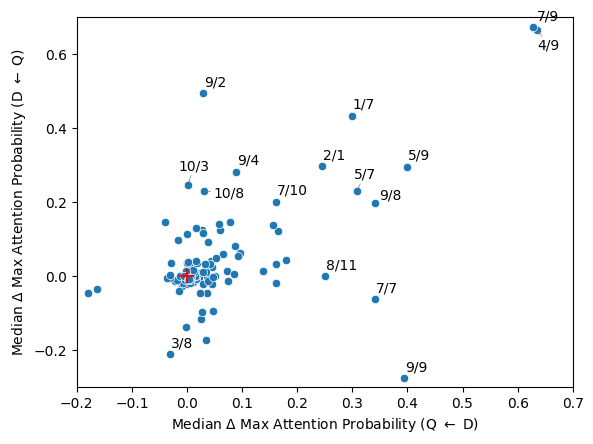

In [ ]:
default_label_kwargs = {
    'fontsize': 12,
    'color': 'black',
    # 'fontweight': 'bold'
}
# default_label_kwargs.update(label_kwargs)


p1 = sns.scatterplot(medians, x="q2d_delta_weak", y="d2q_delta_weak")
texts = []
for point in medians.itertuples():
    if (abs(point.q2d_delta_weak) > 0.2) or (abs(point.d2q_delta_weak) > 0.2):
        text = plt.text(point.q2d_delta_weak, point.d2q_delta_weak, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
        texts.append(text)

if texts:
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), expand=(1.0, 2.0));

p1.set_xlim(-0.2, 0.7)
p1.set_ylim(-0.3, 0.7)
plt.scatter(0, 0, color='red', marker='+', s=100, zorder=10)

p1.xaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (Q $\leftarrow$ D)');
p1.yaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (D $\leftarrow$ Q)');
# p1.figure.savefig(f"{model_id}_msmarco_scatter-d2q-q2d.pdf")

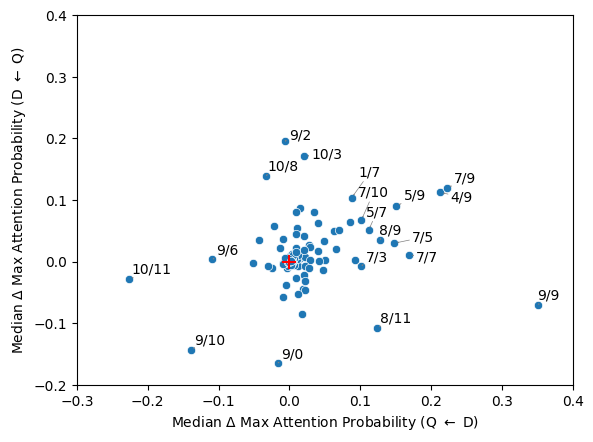

In [ ]:
default_label_kwargs = {
    'fontsize': 12,
    'color': 'black',
    # 'fontweight': 'bold'
}
# default_label_kwargs.update(label_kwargs)


p1 = sns.scatterplot(medians, x="q2d_delta_hard", y="d2q_delta_hard")
texts = []
for point in medians.itertuples():
    if (abs(point.q2d_delta_hard) > 0.1) or (abs(point.d2q_delta_hard) > 0.1):
        text = plt.text(point.q2d_delta_hard, point.d2q_delta_hard, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
        texts.append(text)

if texts:
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), expand=(1.5, 2.0));

p1.set_xlim(-0.3, 0.4)
p1.set_ylim(-0.2, 0.4)
plt.scatter(0, 0, color='red', marker='+', s=100, zorder=10)

p1.xaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (Q $\leftarrow$ D)');
p1.yaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (D $\leftarrow$ Q)');
# p1.figure.savefig(f"{model_id}_msmarco_scatter-d2q-q2d_hard.pdf")

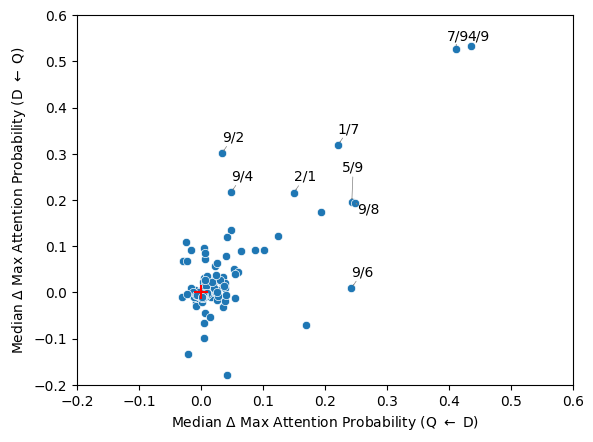

In [ ]:
default_label_kwargs = {
    'fontsize': 12,
    'color': 'black',
    # 'fontweight': 'bold'
}
# default_label_kwargs.update(label_kwargs)


p1 = sns.scatterplot(medians, x="q2d_delta_hard_weak", y="d2q_delta_hard_weak")
texts = []
for point in medians.itertuples():
    if (abs(point.q2d_delta_hard_weak) > 0.2) or (abs(point.d2q_delta_hard_weak) > 0.2):
        text = plt.text(point.q2d_delta_hard_weak, point.d2q_delta_hard_weak, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
        texts.append(text)

if texts:
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), expand=(1.5, 2.5));

p1.set_xlim(-0.2, 0.6)
p1.set_ylim(-0.2, 0.6)
plt.scatter(0, 0, color='red', marker='+', s=100, zorder=10)

p1.xaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (Q $\leftarrow$ D)');
p1.yaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (D $\leftarrow$ Q)');
# p1.figure.savefig(f"{model_id}_msmarco_scatter-d2q-q2d_hard_weak.pdf")

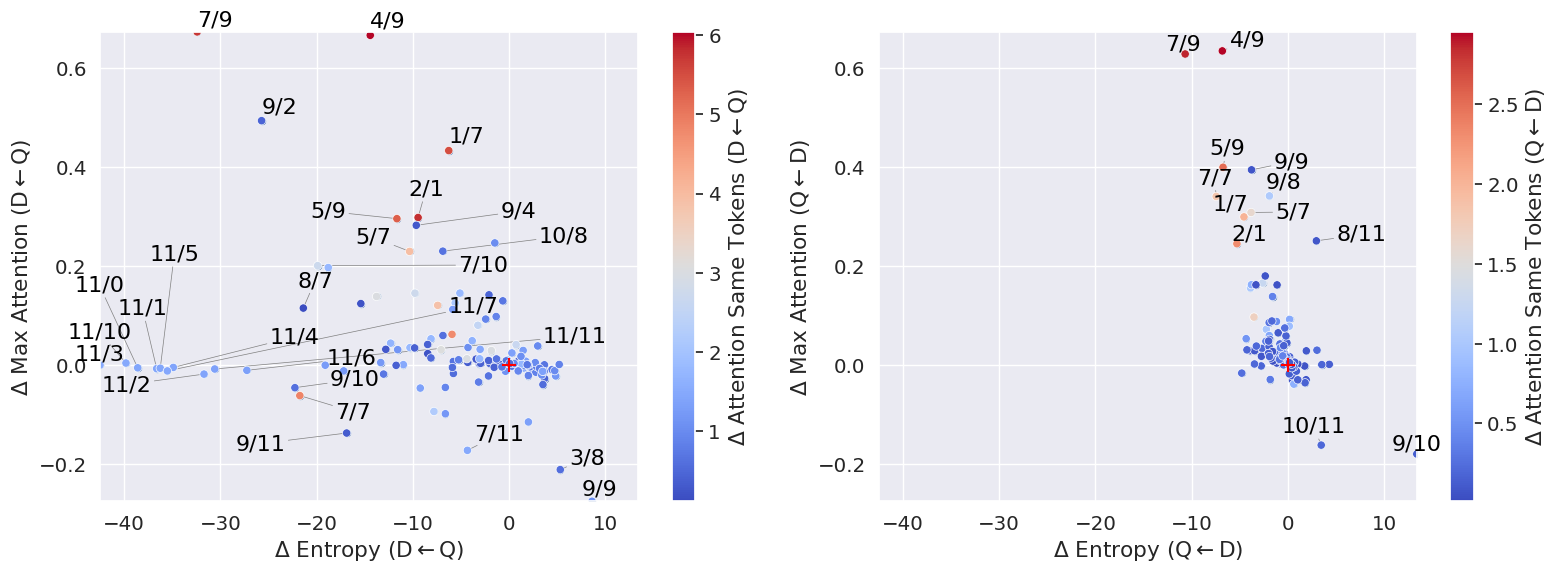

In [23]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

sns.set(font_scale=1.3)

attention_directions = ["d2q", "q2d"]
relevance_level = "weak"
x_values = []
y_values = []

for direction in attention_directions:
    x_col = f"ent_{direction}_delta_{relevance_level}"
    y_col = f"{direction}_delta_{relevance_level}"
    c_col = f"dup_{direction}_delta_{relevance_level}"

    x_values.extend(medians[x_col].values)
    y_values.extend(medians[y_col].values)

# Common limits
xlim = (min(x_values), max(x_values))
ylim = (min(y_values), max(y_values))

default_label_kwargs = {
    'fontsize': 16,
    'color': 'black',
}

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Wider figure to fit two plots side by side

for i, attention_direction in enumerate(attention_directions):
    ax = axes[i]
    
    if attention_direction == "d2q":
        direction = r"(D$\leftarrow$Q)"
    else:
        direction = r"(Q$\leftarrow$D)"

    # First plot (initially without hue)
    sns.scatterplot(
        data=medians,
        x=f"ent_{attention_direction}_delta_{relevance_level}",
        y=f"{attention_direction}_delta_{relevance_level}",
        ax=ax
    )
    ax.scatter(0, 0, color='red', marker='+', s=100, zorder=10)

    texts = []
    for point in medians.itertuples():
        if attention_direction == "d2q":
            if relevance_level == "hard":
                entropy = point.ent_d2q_delta_hard
                diff = point.d2q_delta_hard
            else:
                entropy = point.ent_d2q_delta_weak
                diff = point.d2q_delta_weak
            if (diff > 0.2 and abs(entropy) > 5) or (entropy < -20) or diff < -0.12:
                text = ax.text(entropy, diff, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
                texts.append(text)
        elif attention_direction == "q2d":
            if relevance_level == "hard":
                entropy = point.ent_q2d_delta_hard
                diff = point.q2d_delta_hard
            else:
                entropy = point.ent_q2d_delta_weak
                diff = point.q2d_delta_weak

            if diff > 0.2 or diff < -0.15:
                text = ax.text(entropy, diff, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
                texts.append(text)
        else:
            raise ValueError()
        
    if texts:
        adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), expand=(4.0, 1.0), max_move=(5,5), ax=ax)

    norm = plt.Normalize(
        medians[f"dup_{attention_direction}_delta_{relevance_level}"].min(),
        medians[f"dup_{attention_direction}_delta_{relevance_level}"].max()
    )
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
    sm.set_array([])

    # Plot again with color hue
    sns.scatterplot(
        data=medians,
        x=f"ent_{attention_direction}_delta_{relevance_level}",
        y=f"{attention_direction}_delta_{relevance_level}",
        hue=f"dup_{attention_direction}_delta_{relevance_level}",
        palette="coolwarm",
        legend=None,
        ax=ax,
    )

    ax.set_xlabel(rf'$\Delta$ Entropy {direction}')
    ax.set_ylabel(rf'$\Delta$ Max Attention {direction}')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    fig.colorbar(sm, ax=ax, label=rf'$\Delta$ Attention Same Tokens {direction}')

# Adjust layout
plt.tight_layout()
# plt.savefig(f"matching_analysis_{model_id}_msmarco_{relevance_level}.pdf", format="pdf", bbox_inches='tight')
plt.show()

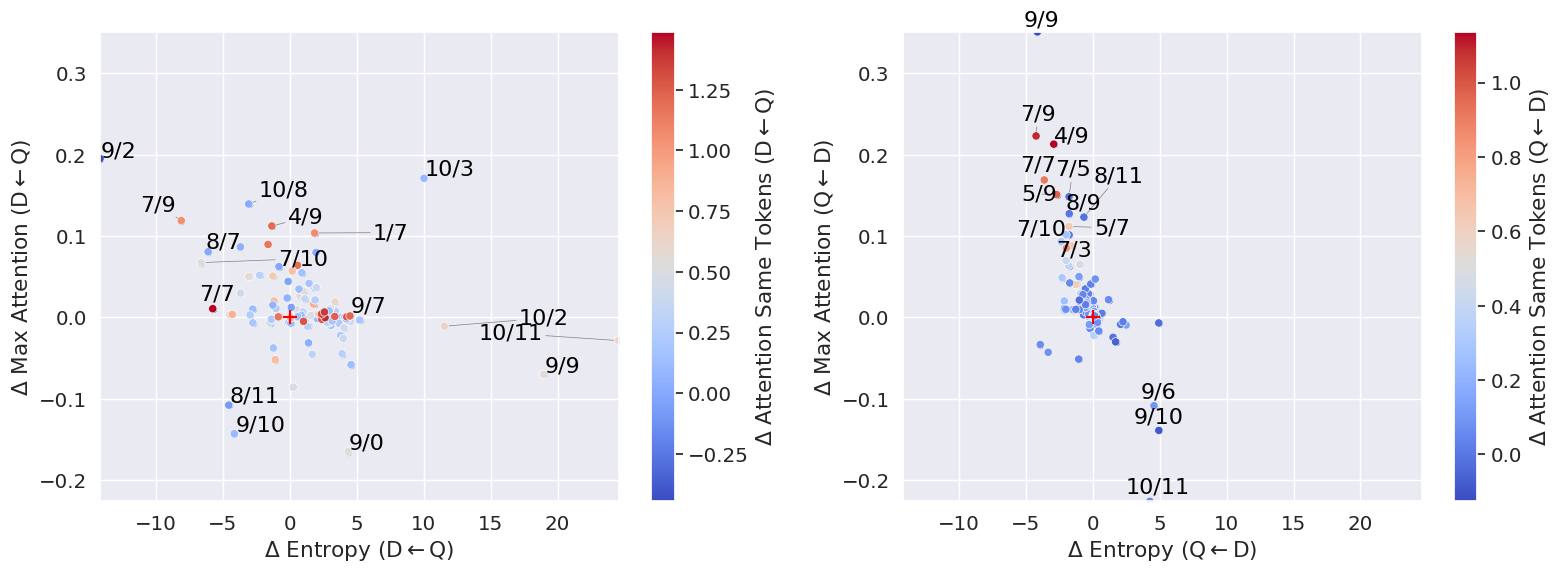

In [53]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

sns.set(font_scale=1.3)

attention_directions = ["d2q", "q2d"]
relevance_level = "hard"
x_values = []
y_values = []

for direction in attention_directions:
    x_col = f"ent_{direction}_delta_{relevance_level}"
    y_col = f"{direction}_delta_{relevance_level}"
    c_col = f"dup_{direction}_delta_{relevance_level}"

    x_values.extend(medians[x_col].values)
    y_values.extend(medians[y_col].values)

# Common limits
xlim = (min(x_values), max(x_values))
ylim = (min(y_values), max(y_values))

default_label_kwargs = {
    'fontsize': 16,
    'color': 'black',
}

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Wider figure to fit two plots side by side

for i, attention_direction in enumerate(attention_directions):
    ax = axes[i]
    
    if attention_direction == "d2q":
        direction = r"(D$\leftarrow$Q)"
    else:
        direction = r"(Q$\leftarrow$D)"

    # First plot (initially without hue)
    sns.scatterplot(
        data=medians,
        x=f"ent_{attention_direction}_delta_{relevance_level}",
        y=f"{attention_direction}_delta_{relevance_level}",
        ax=ax
    )
    ax.scatter(0, 0, color='red', marker='+', s=100, zorder=10)

    texts = []
    for point in medians.itertuples():
        if attention_direction == "d2q":
            if relevance_level == "hard":
                entropy = point.ent_d2q_delta_hard
                diff = point.d2q_delta_hard
            else:
                entropy = point.ent_d2q_delta_weak
                diff = point.d2q_delta_weak
            if (abs(diff) > 0.1 or abs(entropy) > 5):
                text = ax.text(entropy, diff, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
                texts.append(text)
        elif attention_direction == "q2d":
            if relevance_level == "hard":
                entropy = point.ent_q2d_delta_hard
                diff = point.q2d_delta_hard
            else:
                entropy = point.ent_q2d_delta_weak
                diff = point.q2d_delta_weak

            if abs(diff) > 0.1:
                text = ax.text(entropy, diff, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
                texts.append(text)
        else:
            raise ValueError()
        
    if texts:
        adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), expand=(4.0, 1.0), max_move=(5,5), ax=ax)

    norm = plt.Normalize(
        medians[f"dup_{attention_direction}_delta_{relevance_level}"].min(),
        medians[f"dup_{attention_direction}_delta_{relevance_level}"].max()
    )
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
    sm.set_array([])

    # Plot again with color hue
    sns.scatterplot(
        data=medians,
        x=f"ent_{attention_direction}_delta_{relevance_level}",
        y=f"{attention_direction}_delta_{relevance_level}",
        hue=f"dup_{attention_direction}_delta_{relevance_level}",
        palette="coolwarm",
        legend=None,
        ax=ax,
    )

    ax.set_xlabel(rf'$\Delta$ Entropy {direction}')
    ax.set_ylabel(rf'$\Delta$ Max Attention {direction}')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    fig.colorbar(sm, ax=ax, label=rf'$\Delta$ Attention Same Tokens {direction}')

# Adjust layout
plt.tight_layout()
# plt.savefig(f"matching_analysis_{model_id}_msmarco_{relevance_level}.pdf", format="pdf", bbox_inches='tight')
plt.show()

# OOD

In [ ]:
attention_file = "/home/vast/target_dir/relevance-integrations/jobs/src.evd.attention_patterns.summarizeattentionpatterns/c11b867f8e08bbe5a3feed803af852a419da8dd73cd42ce7152e950d55eb368d/dataframes/" # OOD


In [6]:
with gzip.open(attention_file + "/attention.pkl.gz", "rb") as fp:
    try:
        data = pickle.load(fp)    
    except ModuleNotFoundError as e:
        print(f"Missing module: {e.name}")

data.head()
rel_map = {"weak_negative": -1, "non_relevant": 0, "relevant": 1}
data["rel"] = data["rel"].map(rel_map)

In [7]:
with gzip.open(attention_file + "/attention_duplicate_token.pkl.gz", "rb") as fp:
    data_duplicate = pickle.load(fp)    

data_duplicate.rename(columns={"q2d": "dup_q2d", "d2q": "dup_d2q"}, inplace=True)
data_duplicate["rel"] = data_duplicate["rel"].map(rel_map)


In [8]:
with gzip.open(attention_file + "/attention_entropy.pkl.gz", "rb") as fp:
    data_entropy = pickle.load(fp)    

data_entropy.rename(columns={"q2d": "ent_q2d", "d2q": "ent_d2q"}, inplace=True)
data_entropy["rel"] = data_entropy["rel"].map(rel_map)

In [9]:
data_by_query = process_attention(data, data_duplicate, data_entropy)

# Aggregate over queries
medians = data_by_query.groupby(["layer", "head"]).median(numeric_only=True).reset_index()

q2d_max = medians.sort_values(by="q2d_delta_weak", ascending=False)
d2q_max = medians.sort_values(by="d2q_delta_weak", ascending=False)

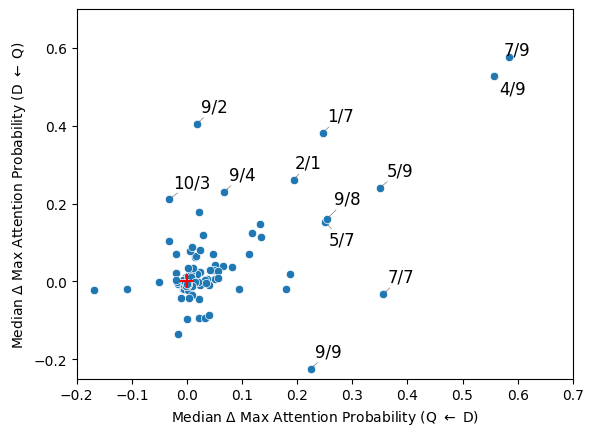

In [13]:
default_label_kwargs = {
    'fontsize': 12,
    'color': 'black',
    # 'fontweight': 'bold'
}
# default_label_kwargs.update(label_kwargs)


p1 = sns.scatterplot(medians, x="q2d_delta_weak", y="d2q_delta_weak")
texts = []
for point in medians.itertuples():
    if (abs(point.q2d_delta_weak) > 0.2) or (abs(point.d2q_delta_weak) > 0.2):
        text = plt.text(point.q2d_delta_weak, point.d2q_delta_weak, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
        texts.append(text)

if texts:
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), expand=(1.5, 2.0));

p1.set_xlim(-0.2, 0.7)
p1.set_ylim(-0.25, 0.7)
plt.scatter(0, 0, color='red', marker='+', s=100, zorder=10)

p1.xaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (Q $\leftarrow$ D)');
p1.yaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (D $\leftarrow$ Q)');
# p1.figure.savefig(f"{model_id}_ood_scatter-d2q-q2d.pdf")

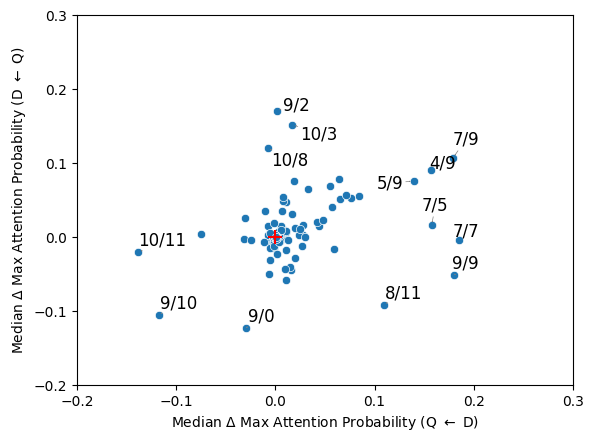

In [16]:
default_label_kwargs = {
    'fontsize': 12,
    'color': 'black',
    # 'fontweight': 'bold'
}
# default_label_kwargs.update(label_kwargs)


p1 = sns.scatterplot(medians, x="q2d_delta_hard", y="d2q_delta_hard")
texts = []
for point in medians.itertuples():
    if (abs(point.q2d_delta_hard) > 0.1) or (abs(point.d2q_delta_hard) > 0.1):
        text = plt.text(point.q2d_delta_hard, point.d2q_delta_hard, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
        texts.append(text)

if texts:
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), expand=(2.0, 2.0));

p1.set_xlim(-0.2, 0.3)
p1.set_ylim(-0.2, 0.3)
plt.scatter(0, 0, color='red', marker='+', s=100, zorder=10)

p1.xaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (Q $\leftarrow$ D)');
p1.yaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (D $\leftarrow$ Q)');
# p1.figure.savefig(f"{model_id}_ood_scatter-d2q-q2d_hard.pdf")

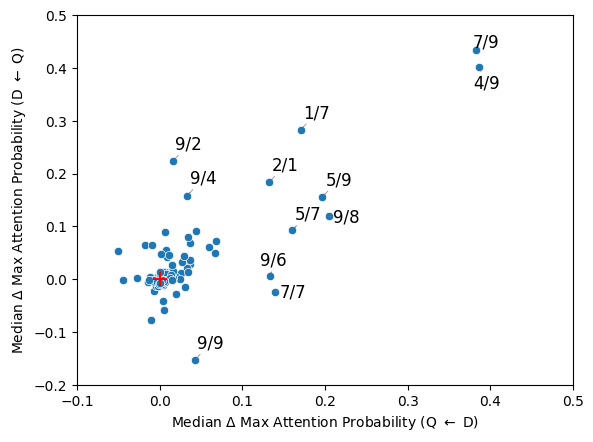

In [17]:
default_label_kwargs = {
    'fontsize': 12,
    'color': 'black',
    # 'fontweight': 'bold'
}
# default_label_kwargs.update(label_kwargs)


p1 = sns.scatterplot(medians, x="q2d_delta_hard_weak", y="d2q_delta_hard_weak")
texts = []
for point in medians.itertuples():
    if (abs(point.q2d_delta_hard_weak) > 0.1) or (abs(point.d2q_delta_hard_weak) > 0.1):
        text = plt.text(point.q2d_delta_hard_weak, point.d2q_delta_hard_weak, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
        texts.append(text)

if texts:
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), expand=(1.5, 2.0));

p1.set_xlim(-0.1, 0.5)
p1.set_ylim(-0.2, 0.5)
plt.scatter(0, 0, color='red', marker='+', s=100, zorder=10)

p1.xaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (Q $\leftarrow$ D)');
p1.yaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (D $\leftarrow$ Q)');
# p1.figure.savefig(f"{model_id}_ood_scatter-d2q-q2d_hard_weak.pdf")

In [ ]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

sns.set(font_scale=1.3)

attention_directions = ["d2q", "q2d"]
relevance_level = "weak"
x_values = []
y_values = []

for direction in attention_directions:
    x_col = f"ent_{direction}_delta_{relevance_level}"
    y_col = f"{direction}_delta_{relevance_level}"
    c_col = f"dup_{direction}_delta_{relevance_level}"

    x_values.extend(medians[x_col].values)
    y_values.extend(medians[y_col].values)

# Common limits
xlim = (min(x_values), max(x_values))
ylim = (min(y_values), max(y_values))

default_label_kwargs = {
    'fontsize': 16,
    'color': 'black',
}

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Wider figure to fit two plots side by side

for i, attention_direction in enumerate(attention_directions):
    ax = axes[i]
    
    if attention_direction == "d2q":
        direction = r"(D$\leftarrow$Q)"
    else:
        direction = r"(Q$\leftarrow$D)"

    # First plot (initially without hue)
    sns.scatterplot(
        data=medians,
        x=f"ent_{attention_direction}_delta_{relevance_level}",
        y=f"{attention_direction}_delta_{relevance_level}",
        ax=ax
    )
    ax.scatter(0, 0, color='red', marker='+', s=100, zorder=10)

    texts = []
    for point in medians.itertuples():
        if attention_direction == "d2q":
            if relevance_level == "hard":
                entropy = point.ent_d2q_delta_hard
                diff = point.d2q_delta_hard
            else:
                entropy = point.ent_d2q_delta_weak
                diff = point.d2q_delta_weak
            if ((abs(diff) > 0.07 and abs(entropy) > 7) or diff < -0.1):
                text = ax.text(entropy, diff, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
                texts.append(text)
        elif attention_direction == "q2d":
            if relevance_level == "hard":
                entropy = point.ent_q2d_delta_hard
                diff = point.q2d_delta_hard
            else:
                entropy = point.ent_q2d_delta_weak
                diff = point.q2d_delta_weak

            if abs(diff) > 0.1:
                text = ax.text(entropy, diff, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
                texts.append(text)
        else:
            raise ValueError()
        
    if texts:
        adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1.5), expand=(1.5, 2.0), max_move=(50, 50), ax=ax)

    norm = plt.Normalize(
        medians[f"dup_{attention_direction}_delta_{relevance_level}"].min(),
        medians[f"dup_{attention_direction}_delta_{relevance_level}"].max()
    )
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
    sm.set_array([])

    # Plot again with color hue
    sns.scatterplot(
        data=medians,
        x=f"ent_{attention_direction}_delta_{relevance_level}",
        y=f"{attention_direction}_delta_{relevance_level}",
        hue=f"dup_{attention_direction}_delta_{relevance_level}",
        palette="coolwarm",
        legend=None,
        ax=ax,
    )

    ax.set_xlabel(rf'$\Delta$ Entropy {direction}')
    ax.set_ylabel(rf'$\Delta$ Max Attention {direction}')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    fig.colorbar(sm, ax=ax, label=rf'$\Delta$ Attention Same Tokens {direction}')

# Adjust layout
plt.tight_layout()
# plt.savefig(f"matching_analysis_{model_id}_ood_{relevance_level}.pdf", format="pdf", bbox_inches='tight')
plt.show()

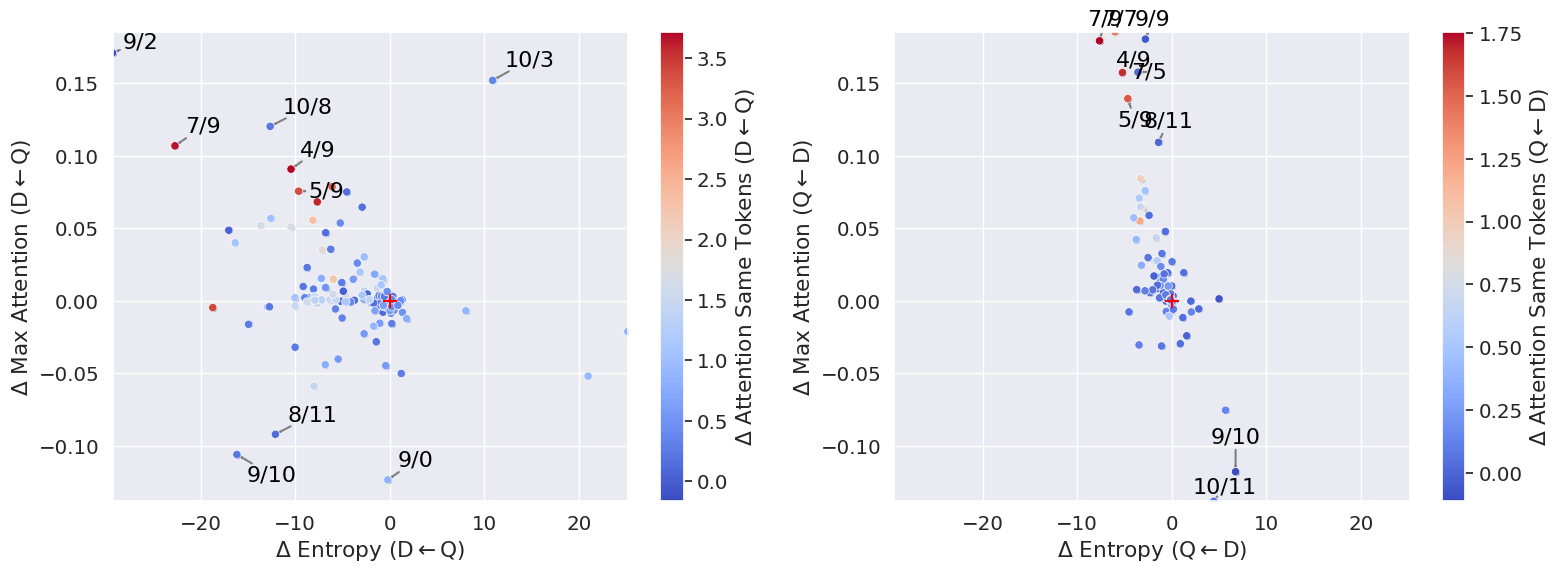

In [21]:
import matplotlib.pyplot as plt
import seaborn as sns
from adjustText import adjust_text

sns.set(font_scale=1.3)

attention_directions = ["d2q", "q2d"]
relevance_level = "hard"
x_values = []
y_values = []

for direction in attention_directions:
    x_col = f"ent_{direction}_delta_{relevance_level}"
    y_col = f"{direction}_delta_{relevance_level}"
    c_col = f"dup_{direction}_delta_{relevance_level}"

    x_values.extend(medians[x_col].values)
    y_values.extend(medians[y_col].values)

# Common limits
xlim = (min(x_values), max(x_values))
ylim = (min(y_values), max(y_values))

default_label_kwargs = {
    'fontsize': 16,
    'color': 'black',
}

# Create subplots: 1 row, 2 columns
fig, axes = plt.subplots(1, 2, figsize=(16, 6))  # Wider figure to fit two plots side by side

for i, attention_direction in enumerate(attention_directions):
    ax = axes[i]
    
    if attention_direction == "d2q":
        direction = r"(D$\leftarrow$Q)"
    else:
        direction = r"(Q$\leftarrow$D)"

    # First plot (initially without hue)
    sns.scatterplot(
        data=medians,
        x=f"ent_{attention_direction}_delta_{relevance_level}",
        y=f"{attention_direction}_delta_{relevance_level}",
        ax=ax
    )
    ax.scatter(0, 0, color='red', marker='+', s=100, zorder=10)

    texts = []
    for point in medians.itertuples():
        if attention_direction == "d2q":
            if relevance_level == "hard":
                entropy = point.ent_d2q_delta_hard
                diff = point.d2q_delta_hard
            else:
                entropy = point.ent_d2q_delta_weak
                diff = point.d2q_delta_weak
            if ((abs(diff) > 0.07 and abs(entropy) > 7) or diff < -0.1):
                text = ax.text(entropy, diff, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
                texts.append(text)
        elif attention_direction == "q2d":
            if relevance_level == "hard":
                entropy = point.ent_q2d_delta_hard
                diff = point.q2d_delta_hard
            else:
                entropy = point.ent_q2d_delta_weak
                diff = point.q2d_delta_weak

            if abs(diff) > 0.1:
                text = ax.text(entropy, diff, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
                texts.append(text)
        else:
            raise ValueError()
        
    if texts:
        adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=1.5), expand=(1.5, 2.0), max_move=(50, 50), ax=ax)

    norm = plt.Normalize(
        medians[f"dup_{attention_direction}_delta_{relevance_level}"].min(),
        medians[f"dup_{attention_direction}_delta_{relevance_level}"].max()
    )
    sm = plt.cm.ScalarMappable(cmap="coolwarm", norm=norm)
    sm.set_array([])

    # Plot again with color hue
    sns.scatterplot(
        data=medians,
        x=f"ent_{attention_direction}_delta_{relevance_level}",
        y=f"{attention_direction}_delta_{relevance_level}",
        hue=f"dup_{attention_direction}_delta_{relevance_level}",
        palette="coolwarm",
        legend=None,
        ax=ax,
    )

    ax.set_xlabel(rf'$\Delta$ Entropy {direction}')
    ax.set_ylabel(rf'$\Delta$ Max Attention {direction}')
    ax.set_xlim(xlim)
    ax.set_ylim(ylim)

    fig.colorbar(sm, ax=ax, label=rf'$\Delta$ Attention Same Tokens {direction}')

# Adjust layout
plt.tight_layout()
# plt.savefig(f"matching_analysis_{model_id}_ood_{relevance_level}.pdf", format="pdf", bbox_inches='tight')
plt.show()

# ALL

In [ ]:
attention_file = "/home/vast/target_dir/relevance-integrations/jobs/src.evd.attention_patterns.summarizeattentionpatterns/a38d08719531b43086f10e79de082a0de97cccf5a17ba38f6f08e125c598c928/dataframes/" # ALL


In [5]:
with gzip.open(attention_file + "/attention.pkl.gz", "rb") as fp:
    try:
        data = pickle.load(fp)    
    except ModuleNotFoundError as e:
        print(f"Missing module: {e.name}")

data.head()
rel_map = {"weak_negative": -1, "non_relevant": 0, "relevant": 1}
data["rel"] = data["rel"].map(rel_map)

In [6]:
with gzip.open(attention_file + "/attention_duplicate_token.pkl.gz", "rb") as fp:
    data_duplicate = pickle.load(fp)    

data_duplicate.rename(columns={"q2d": "dup_q2d", "d2q": "dup_d2q"}, inplace=True)
data_duplicate["rel"] = data_duplicate["rel"].map(rel_map)


In [7]:
with gzip.open(attention_file + "/attention_entropy.pkl.gz", "rb") as fp:
    data_entropy = pickle.load(fp)    

data_entropy.rename(columns={"q2d": "ent_q2d", "d2q": "ent_d2q"}, inplace=True)
data_entropy["rel"] = data_entropy["rel"].map(rel_map)

In [8]:
data_by_query = process_attention(data, data_duplicate, data_entropy)

# Aggregate over queries
medians = data_by_query.groupby(["layer", "head"]).median(numeric_only=True).reset_index()

q2d_max = medians.sort_values(by="q2d_delta_weak", ascending=False)
d2q_max = medians.sort_values(by="d2q_delta_weak", ascending=False)

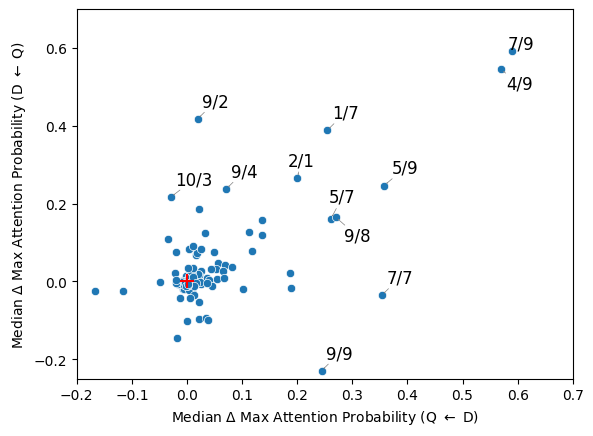

In [9]:
default_label_kwargs = {
    'fontsize': 12,
    'color': 'black',
    # 'fontweight': 'bold'
}
# default_label_kwargs.update(label_kwargs)


p1 = sns.scatterplot(medians, x="q2d_delta_weak", y="d2q_delta_weak")
texts = []
for point in medians.itertuples():
    if (abs(point.q2d_delta_weak) > 0.2) or (abs(point.d2q_delta_weak) > 0.2):
        text = plt.text(point.q2d_delta_weak, point.d2q_delta_weak, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
        texts.append(text)

if texts:
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), expand=(1.5, 2.0));

p1.set_xlim(-0.2, 0.7)
p1.set_ylim(-0.25, 0.7)
plt.scatter(0, 0, color='red', marker='+', s=100, zorder=10)

p1.xaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (Q $\leftarrow$ D)');
p1.yaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (D $\leftarrow$ Q)');
# p1.figure.savefig(f"{model_id}_all_scatter-d2q-q2d.pdf")

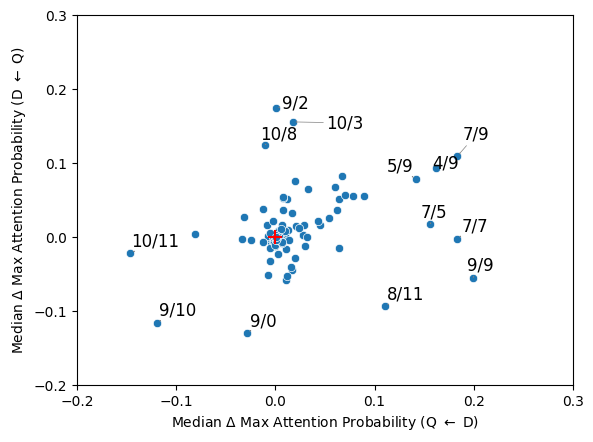

In [10]:
default_label_kwargs = {
    'fontsize': 12,
    'color': 'black',
    # 'fontweight': 'bold'
}
# default_label_kwargs.update(label_kwargs)


p1 = sns.scatterplot(medians, x="q2d_delta_hard", y="d2q_delta_hard")
texts = []
for point in medians.itertuples():
    if (abs(point.q2d_delta_hard) > 0.1) or (abs(point.d2q_delta_hard) > 0.1):
        text = plt.text(point.q2d_delta_hard, point.d2q_delta_hard, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
        texts.append(text)

if texts:
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), expand=(2.0, 2.0));

p1.set_xlim(-0.2, 0.3)
p1.set_ylim(-0.2, 0.3)
plt.scatter(0, 0, color='red', marker='+', s=100, zorder=10)

p1.xaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (Q $\leftarrow$ D)');
p1.yaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (D $\leftarrow$ Q)');
# p1.figure.savefig(f"{model_id}_all_scatter-d2q-q2d_hard.pdf")

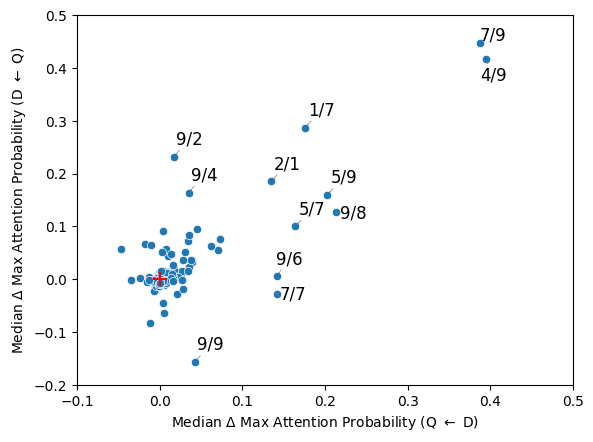

In [11]:
default_label_kwargs = {
    'fontsize': 12,
    'color': 'black',
    # 'fontweight': 'bold'
}
# default_label_kwargs.update(label_kwargs)


p1 = sns.scatterplot(medians, x="q2d_delta_hard_weak", y="d2q_delta_hard_weak")
texts = []
for point in medians.itertuples():
    if (abs(point.q2d_delta_hard_weak) > 0.1) or (abs(point.d2q_delta_hard_weak) > 0.1):
        text = plt.text(point.q2d_delta_hard_weak, point.d2q_delta_hard_weak, f"{point.layer}/{point.head}", ha="left", va="bottom", **default_label_kwargs)
        texts.append(text)

if texts:
    adjust_text(texts, arrowprops=dict(arrowstyle='->', color='gray', lw=0.5), expand=(1.5, 2.0));

p1.set_xlim(-0.1, 0.5)
p1.set_ylim(-0.2, 0.5)
plt.scatter(0, 0, color='red', marker='+', s=100, zorder=10)

p1.xaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (Q $\leftarrow$ D)');
p1.yaxis.set_label_text(r'Median $\Delta$ Max Attention Probability (D $\leftarrow$ Q)');
# p1.figure.savefig(f"{model_id}_all_scatter-d2q-q2d_hard_weak.pdf")